# Leverage deployment guardrails to update a SageMaker Inference endpoint using linear traffic shifting


---

This notebook's CI test result for us-west-2 is as follows. CI test results in other regions can be found at the end of the notebook. 

![This us-west-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-west-2/deploy_and_monitor|sm-deployment_guardrails_update_inference_endpoint_with_linear_traffic_shifting|sm-deployment_guardrails_update_inference_endpoint_with_linear_traffic_shifting.ipynb)

---


SageMaker Studio Kernel: Data Science

# Contents

 - [Introduction](#Introduction)
 - [Setup](#Setup)
 - [Step 1: Create and deploy the pre-trained models](#Step1)
 - [Step 2: Invoke Endpoint](#Step2)
 - [Step 3: Create CloudWatch alarms to monitor Endpoint performance](#Step3)
 - [Step 4: Update Endpoint with deployment configurations- Linear Traffic Shifting](#Step4)
 - [Cleanup](#Clenup)

# Introduction <a id='Introduction'></a>

Deployment guardrails are a set of model deployment options in Amazon SageMaker Inference to update your machine learning models in production. Using the fully managed deployment guardrails options, you can control the switch from the current model in production to a new one. Traffic shifting modes, such as canary and linear, give you granular control over the traffic shifting process from your current model to the new one during the course of the update. There are also built-in safeguards such as auto-rollbacks that help you catch issues early and take corrective action before they impact production.

We support blue-green deployment with multiple traffic shifting modes. A traffic shifting mode is a configuration that specifies how endpoint traffic is routed to a new fleet containing your updates. The following traffic shifting modes provide you with different levels of control over the endpoint update process:

* **All-At-Once Traffic Shifting** : shifts all of your endpoint traffic from the blue fleet to the green fleet. Once the traffic has shifted to the green fleet, your pre-specified Amazon CloudWatch alarms begin monitoring the green fleet for a set amount of time (the “baking period”). If no alarms are triggered during the baking period, then the blue fleet is terminated.
* **Canary Traffic Shifting** : lets you shift one small portion of your traffic (a “canary”) to the green fleet and monitor it for a baking period. If the canary succeeds on the green fleet, then the rest of the traffic is shifted from the blue fleet to the green fleet before terminating the blue fleet.
* **Linear Traffic Shifting** : provides even more customization over how many traffic-shifting steps to make and what percentage of traffic to shift for each step. While canary shifting lets you shift traffic in two steps, linear shifting extends this to n number of linearly spaced steps.


The Deployment guardrails for Amazon SageMaker Inference endpoints feature also allows customers to specify conditions/alarms based on Endpoint invocation metrics from CloudWatch to detect model performance regressions and trigger automatic rollback.

In this notebook we'll update endpoint with following deployment configurations:
 * Blue/Green update policy with **Linear traffic shifting option**
 * Configure CloudWatch alarms to monitor model performance and trigger auto-rollback action.
  
To demonstrate Linear deployments and the auto-rollback feature, we will update an Endpoint with an incompatible model version and deploy it as a Linear fleet, taking a small percentage of the traffic. Requests sent to this Linear fleet will result in errors, which will be used to trigger a rollback using pre-specified CloudWatch alarms. Finally, we will also demonstrate a success scenario where no alarms are tripped and the update succeeds. 

This notebook is organized in 4 steps -
* Step 1 creates the models and Endpoint Configurations required for the 3 scenarios - the baseline, the update containing the incompatible model version and the update containing the correct model version. 
* Step 2 invokes the baseline Endpoint prior to the update. 
* Step 3 specifies the CloudWatch alarms used to trigger the rollbacks. 
* Finally in step 4, we update the endpoint to trigger a rollback and demonstrate a successful update. 

# Setup <a id='Setup'></a>

First we ensure we have an updated version of boto3, which includes the latest SageMaker features:

In [1]:
# [exec-copy] pip installs disabled; env already has V3 + awscli


Let's set up some required imports and basic initial variables:

In [2]:
%matplotlib inline

import time
import os
import boto3
import botocore
import re
import json
from datetime import datetime, timedelta, timezone
# V3: SageMaker Session and get_execution_role now live in sagemaker-core
from sagemaker.core.helper.session_helper import Session, get_execution_role
# V3: S3 utilities now live in sagemaker-core (S3Downloader unused, dropped)
from sagemaker.core.s3 import S3Uploader

region = "us-west-1"  # [exec-copy] pinned region

# You can use a different IAM role with SageMakerFullAccess policy for this notebook
role = "arn:aws:iam::729646638167:role/service-role/AmazonSageMaker-ExecutionRole-20251201T194045"  # [exec-copy] explicit execution role
print(f"Execution role: {role}")

sm_session = Session(boto_session=boto3.Session())
sm = boto3.Session().client("sagemaker")
sm_runtime = boto3.Session().client("sagemaker-runtime")

# You can use a different bucket, but make sure the role you chose for this notebook
# has the s3:PutObject permissions. This is the bucket into which the model artifacts will be uploaded
bucket = sm_session.default_bucket()
prefix = "sagemaker/DEMO-Deployment-Guardrails-Linear"
default_bucket_prefix = sm_session.default_bucket_prefix

# If a default bucket prefix is specified, append it to the s3 path
if default_bucket_prefix:
    prefix = f"{default_bucket_prefix}/{prefix}"

/Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/pydantic/_internal/_fields.py:128: UserWarning: Field "model_data_url" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
/Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/pydantic/_internal/_fields.py:128: UserWarning: Field "model_data_source" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
/Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/pydantic/_internal/_fields.py:128: UserWarning: Field "model_description" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
/Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/

Execution role: arn:aws:iam::729646638167:role/service-role/AmazonSageMaker-ExecutionRole-20251201T194045


[07/16/26 13:31:44] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=7933175;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=7933176;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

sagemaker.config INFO - Not applying SDK defaults from location: /Library/Application Support/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /Users/lucasjia/Library/Application Support/sagemaker/config.yaml


[07/16/26 13:31:45] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=7933181;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=7933182;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

                    INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=7933187;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=7933188;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

Download the Input files and pre-trained model from S3 bucket

In [3]:
!mkdir model
s3 = boto3.client("s3")
s3.download_file(
    f"sagemaker-example-files-prod-{region}",
    "models/xgb-churn/xgb-churn-prediction-model.tar.gz",
    "model/xgb-churn-prediction-model.tar.gz",
)
s3.download_file(
    f"sagemaker-example-files-prod-{region}",
    "models/xgb-churn/xgb-churn-prediction-model2.tar.gz",
    "model/xgb-churn-prediction-model2.tar.gz",
)

!mkdir test_data
s3.download_file(
    f"sagemaker-example-files-prod-{region}",
    "datasets/tabular/xgb-churn/test-dataset.csv",
    "test_data/test-dataset.csv",
)
s3.download_file(
    f"sagemaker-example-files-prod-{region}",
    "datasets/tabular/xgb-churn/test-dataset-input-cols.csv",
    "test_data/test-dataset-input-cols.csv",
)

mkdir: model: File exists


[07/16/26 13:31:46] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=7933193;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=7933194;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

mkdir: test_data: File exists


# Step 1: Create and deploy the models <a id='Step1'></a>

### First, we upload our pre-trained models to Amazon S3
This code uploads two pre-trained XGBoost models that are ready for you to deploy. These models were trained using the [XGB Churn Prediction Notebook](https://github.com/aws/amazon-sagemaker-examples/blob/master/introduction_to_applying_machine_learning/xgboost_customer_churn/xgboost_customer_churn.ipynb) in SageMaker. You can also use your own pre-trained models in this step. If you already have a pretrained model in Amazon S3, you can add it by specifying the s3_key.

The models in this example are used to predict the probability of a mobile customer leaving their current mobile operator. The dataset we use is publicly available and was mentioned in the book [Discovering Knowledge in Data](https://www.amazon.com/dp/0470908742/) by Daniel T. Larose. It is attributed by the author to the University of California Irvine Repository of Machine Learning Datasets.

In [4]:
model_url = S3Uploader.upload(
    local_path="model/xgb-churn-prediction-model.tar.gz",
    desired_s3_uri=f"s3://{bucket}/{prefix}",
)
model_url2 = S3Uploader.upload(
    local_path="model/xgb-churn-prediction-model2.tar.gz",
    desired_s3_uri=f"s3://{bucket}/{prefix}",
)

print(f"Model URI 1: {model_url}")
print(f"Model URI 2: {model_url2}")

Model URI 1: s3://sagemaker-us-west-1-729646638167/sagemaker/DEMO-Deployment-Guardrails-Linear/xgb-churn-prediction-model.tar.gz
Model URI 2: s3://sagemaker-us-west-1-729646638167/sagemaker/DEMO-Deployment-Guardrails-Linear/xgb-churn-prediction-model2.tar.gz


### Next, we create our model definitions
Start with deploying the pre-trained churn prediction models. Here, you create the model objects with the image and model data.

In [5]:
# V3: image_uris now lives in sagemaker-core
from sagemaker.core import image_uris

image_uri = image_uris.retrieve("xgboost", boto3.Session().region_name, "0.90-1")

# Using newer version of XGBoost which is incompatible, in order to simulate model faults
image_uri2 = image_uris.retrieve("xgboost", boto3.Session().region_name, "1.2-1")
image_uri3 = image_uris.retrieve("xgboost", boto3.Session().region_name, "0.90-2")

print(f"Model Image 1: {image_uri}")
print(f"Model Image 2: {image_uri2}")
print(f"Model Image 3: {image_uri3}")

                    INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=7933199;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=7933200;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

/Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/pydantic/_internal/_fields.py:128: UserWarning: Field "model_id" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
/Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/pydantic/_internal/_fields.py:128: UserWarning: Field "model_version" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(


[07/16/26 13:31:47] INFO     Defaulting to only available Python version: py3                     ]8;id=7933207;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py\image_uris.py]8;;\:]8;id=7933208;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py#615\615]8;;\

                    INFO     Defaulting to only supported image scope: cpu.                       ]8;id=7933214;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py\image_uris.py]8;;\:]8;id=7933215;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py#539\539]8;;\

                    INFO     Ignoring unnecessary instance type: None.                            ]8;id=7933221;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py\image_uris.py]8;;\:]8;id=7933222;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py#535\535]8;;\

                    INFO     Defaulting to only available Python version: py3                     ]8;id=7933227;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py\image_uris.py]8;;\:]8;id=7933228;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py#615\615]8;;\

                    INFO     Defaulting to only supported image scope: cpu.                       ]8;id=7933233;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py\image_uris.py]8;;\:]8;id=7933234;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py#539\539]8;;\

Model Image 1: 746614075791.dkr.ecr.us-west-1.amazonaws.com/sagemaker-xgboost:0.90-1-cpu-py3
Model Image 2: 746614075791.dkr.ecr.us-west-1.amazonaws.com/sagemaker-xgboost:1.2-1
Model Image 3: 746614075791.dkr.ecr.us-west-1.amazonaws.com/sagemaker-xgboost:0.90-2-cpu-py3


In [6]:
model_name = f"DEMO-xgb-churn-pred-{datetime.now():%Y-%m-%d-%H-%M-%S}"
model_name2 = f"DEMO-xgb-churn-pred2-{datetime.now():%Y-%m-%d-%H-%M-%S}"
model_name3 = f"DEMO-xgb-churn-pred3-{datetime.now():%Y-%m-%d-%H-%M-%S}"

print(f"Model Name 1: {model_name}")
print(f"Model Name 2: {model_name2}")
print(f"Model Name 3: {model_name3}")

resp = sm.create_model(
    ModelName=model_name,
    ExecutionRoleArn=role,
    Containers=[{"Image": image_uri, "ModelDataUrl": model_url}],
)
print(f"Created Model: {resp}")

resp = sm.create_model(
    ModelName=model_name2,
    ExecutionRoleArn=role,
    Containers=[{"Image": image_uri2, "ModelDataUrl": model_url2}],
)
print(f"Created Model: {resp}")

resp = sm.create_model(
    ModelName=model_name3,
    ExecutionRoleArn=role,
    Containers=[{"Image": image_uri3, "ModelDataUrl": model_url2}],
)
print(f"Created Model: {resp}")

Model Name 1: DEMO-xgb-churn-pred-2026-07-16-13-31-47
Model Name 2: DEMO-xgb-churn-pred2-2026-07-16-13-31-47
Model Name 3: DEMO-xgb-churn-pred3-2026-07-16-13-31-47


Created Model: {'ModelArn': 'arn:aws:sagemaker:us-west-1:729646638167:model/DEMO-xgb-churn-pred-2026-07-16-13-31-47', 'ResponseMetadata': {'RequestId': 'd4e21429-024a-45b2-be09-1f155e87c459', 'HTTPStatusCode': 200, 'HTTPHeaders': {'x-amzn-requestid': 'd4e21429-024a-45b2-be09-1f155e87c459', 'strict-transport-security': 'max-age=47304000; includeSubDomains', 'x-frame-options': 'DENY', 'content-security-policy': "frame-ancestors 'none'", 'cache-control': 'no-cache, no-store, must-revalidate', 'x-content-type-options': 'nosniff', 'content-type': 'application/x-amz-json-1.1', 'content-length': '101', 'date': 'Thu, 16 Jul 2026 20:31:47 GMT'}, 'RetryAttempts': 0}}


Created Model: {'ModelArn': 'arn:aws:sagemaker:us-west-1:729646638167:model/DEMO-xgb-churn-pred2-2026-07-16-13-31-47', 'ResponseMetadata': {'RequestId': '3b7db445-b533-4a29-9d54-4ba379153f48', 'HTTPStatusCode': 200, 'HTTPHeaders': {'x-amzn-requestid': '3b7db445-b533-4a29-9d54-4ba379153f48', 'strict-transport-security': 'max-age=47304000; includeSubDomains', 'x-frame-options': 'DENY', 'content-security-policy': "frame-ancestors 'none'", 'cache-control': 'no-cache, no-store, must-revalidate', 'x-content-type-options': 'nosniff', 'content-type': 'application/x-amz-json-1.1', 'content-length': '102', 'date': 'Thu, 16 Jul 2026 20:31:49 GMT'}, 'RetryAttempts': 2}}


Created Model: {'ModelArn': 'arn:aws:sagemaker:us-west-1:729646638167:model/DEMO-xgb-churn-pred3-2026-07-16-13-31-47', 'ResponseMetadata': {'RequestId': 'eaeb5f9e-7685-428f-8bc4-125370b60512', 'HTTPStatusCode': 200, 'HTTPHeaders': {'x-amzn-requestid': 'eaeb5f9e-7685-428f-8bc4-125370b60512', 'strict-transport-security': 'max-age=47304000; includeSubDomains', 'x-frame-options': 'DENY', 'content-security-policy': "frame-ancestors 'none'", 'cache-control': 'no-cache, no-store, must-revalidate', 'x-content-type-options': 'nosniff', 'content-type': 'application/x-amz-json-1.1', 'content-length': '102', 'date': 'Thu, 16 Jul 2026 20:31:50 GMT'}, 'RetryAttempts': 2}}


### Create Endpoint Configs

We now create three EndpointConfigs, each with its own different model (these could also have different instance types).


In [7]:
ep_config_name = f"DEMO-EpConfig-1-{datetime.now():%Y-%m-%d-%H-%M-%S}"
ep_config_name2 = f"DEMO-EpConfig-2-{datetime.now():%Y-%m-%d-%H-%M-%S}"
ep_config_name3 = f"DEMO-EpConfig-3-{datetime.now():%Y-%m-%d-%H-%M-%S}"

print(f"Endpoint Config 1: {ep_config_name}")
print(f"Endpoint Config 2: {ep_config_name2}")
print(f"Endpoint Config 3: {ep_config_name3}")

resp = sm.create_endpoint_config(
    EndpointConfigName=ep_config_name,
    ProductionVariants=[
        {
            "VariantName": "AllTraffic",
            "ModelName": model_name,
            "InstanceType": "ml.m5.xlarge",
            "InitialInstanceCount": 3,
        }
    ],
)
print(f"Created Endpoint Config: {resp}")
time.sleep(5)

resp = sm.create_endpoint_config(
    EndpointConfigName=ep_config_name2,
    ProductionVariants=[
        {
            "VariantName": "AllTraffic",
            "ModelName": model_name2,
            "InstanceType": "ml.m5.xlarge",
            "InitialInstanceCount": 3,
        }
    ],
)
print(f"Created Endpoint Config: {resp}")
time.sleep(5)

resp = sm.create_endpoint_config(
    EndpointConfigName=ep_config_name3,
    ProductionVariants=[
        {
            "VariantName": "AllTraffic",
            "ModelName": model_name3,
            "InstanceType": "ml.m5.xlarge",
            "InitialInstanceCount": 3,
        }
    ],
)
print(f"Created Endpoint Config: {resp}")
time.sleep(5)

Endpoint Config 1: DEMO-EpConfig-1-2026-07-16-13-31-50
Endpoint Config 2: DEMO-EpConfig-2-2026-07-16-13-31-50
Endpoint Config 3: DEMO-EpConfig-3-2026-07-16-13-31-50


Created Endpoint Config: {'EndpointConfigArn': 'arn:aws:sagemaker:us-west-1:729646638167:endpoint-config/DEMO-EpConfig-1-2026-07-16-13-31-50', 'ResponseMetadata': {'RequestId': '2815cf98-47eb-4a5f-a38c-f104e353bccc', 'HTTPStatusCode': 200, 'HTTPHeaders': {'x-amzn-requestid': '2815cf98-47eb-4a5f-a38c-f104e353bccc', 'strict-transport-security': 'max-age=47304000; includeSubDomains', 'x-frame-options': 'DENY', 'content-security-policy': "frame-ancestors 'none'", 'cache-control': 'no-cache, no-store, must-revalidate', 'x-content-type-options': 'nosniff', 'content-type': 'application/x-amz-json-1.1', 'content-length': '116', 'date': 'Thu, 16 Jul 2026 20:31:51 GMT'}, 'RetryAttempts': 0}}


Created Endpoint Config: {'EndpointConfigArn': 'arn:aws:sagemaker:us-west-1:729646638167:endpoint-config/DEMO-EpConfig-2-2026-07-16-13-31-50', 'ResponseMetadata': {'RequestId': '74403c99-da50-4052-b877-ee1ff55e1778', 'HTTPStatusCode': 200, 'HTTPHeaders': {'x-amzn-requestid': '74403c99-da50-4052-b877-ee1ff55e1778', 'strict-transport-security': 'max-age=47304000; includeSubDomains', 'x-frame-options': 'DENY', 'content-security-policy': "frame-ancestors 'none'", 'cache-control': 'no-cache, no-store, must-revalidate', 'x-content-type-options': 'nosniff', 'content-type': 'application/x-amz-json-1.1', 'content-length': '116', 'date': 'Thu, 16 Jul 2026 20:31:56 GMT'}, 'RetryAttempts': 0}}


Created Endpoint Config: {'EndpointConfigArn': 'arn:aws:sagemaker:us-west-1:729646638167:endpoint-config/DEMO-EpConfig-3-2026-07-16-13-31-50', 'ResponseMetadata': {'RequestId': '5dc948a1-08fc-4f19-93db-03414aaaeec4', 'HTTPStatusCode': 200, 'HTTPHeaders': {'x-amzn-requestid': '5dc948a1-08fc-4f19-93db-03414aaaeec4', 'strict-transport-security': 'max-age=47304000; includeSubDomains', 'x-frame-options': 'DENY', 'content-security-policy': "frame-ancestors 'none'", 'cache-control': 'no-cache, no-store, must-revalidate', 'x-content-type-options': 'nosniff', 'content-type': 'application/x-amz-json-1.1', 'content-length': '116', 'date': 'Thu, 16 Jul 2026 20:32:01 GMT'}, 'RetryAttempts': 0}}


### Create Endpoint

Let's go ahead and deploy the model to a SageMaker endpoint:

In [8]:
endpoint_name = f"DEMO-Deployment-Guardrails-Linear-{datetime.now():%Y-%m-%d-%H-%M-%S}"
print(f"Endpoint Name: {endpoint_name}")

# creating endpoint with the first endpoint config (ep_config_name)
resp = sm.create_endpoint(EndpointName=endpoint_name, EndpointConfigName=ep_config_name)
print(f"\nCreated Endpoint: {resp}")

Endpoint Name: DEMO-Deployment-Guardrails-Linear-2026-07-16-13-32-06



Created Endpoint: {'EndpointArn': 'arn:aws:sagemaker:us-west-1:729646638167:endpoint/DEMO-Deployment-Guardrails-Linear-2026-07-16-13-32-06', 'ResponseMetadata': {'RequestId': '17ca640f-87d4-4816-82f6-7ccec1b2e1f1', 'HTTPStatusCode': 200, 'HTTPHeaders': {'x-amzn-requestid': '17ca640f-87d4-4816-82f6-7ccec1b2e1f1', 'strict-transport-security': 'max-age=47304000; includeSubDomains', 'x-frame-options': 'DENY', 'content-security-policy': "frame-ancestors 'none'", 'cache-control': 'no-cache, no-store, must-revalidate', 'x-content-type-options': 'nosniff', 'content-type': 'application/x-amz-json-1.1', 'content-length': '121', 'date': 'Thu, 16 Jul 2026 20:32:07 GMT'}, 'RetryAttempts': 0}}


Wait for the endpoint creation to complete.

In [9]:
def wait_for_endpoint_in_service(endpoint_name):
    print("Waiting for endpoint in service")
    while True:
        details = sm.describe_endpoint(EndpointName=endpoint_name)
        status = details["EndpointStatus"]
        if status in ["InService", "Failed"]:
            print("\nDone!")
            break
        print(".", end="", flush=True)
        time.sleep(30)


wait_for_endpoint_in_service(endpoint_name)

sm.describe_endpoint(EndpointName=endpoint_name)

Waiting for endpoint in service
.

.

.

.

.

.


Done!


{'EndpointName': 'DEMO-Deployment-Guardrails-Linear-2026-07-16-13-32-06',
 'EndpointArn': 'arn:aws:sagemaker:us-west-1:729646638167:endpoint/DEMO-Deployment-Guardrails-Linear-2026-07-16-13-32-06',
 'EndpointConfigName': 'DEMO-EpConfig-1-2026-07-16-13-31-50',
 'ProductionVariants': [{'VariantName': 'AllTraffic',
   'DeployedImages': [{'SpecifiedImage': '746614075791.dkr.ecr.us-west-1.amazonaws.com/sagemaker-xgboost:0.90-1-cpu-py3',
     'ResolvedImage': '746614075791.dkr.ecr.us-west-1.amazonaws.com/sagemaker-xgboost@sha256:4814427c3e0a6cf99e637704da3ada04219ac7cd5727ff62284153761d36d7d3',
     'ResolutionTime': datetime.datetime(2026, 7, 16, 13, 32, 7, 499000, tzinfo=tzlocal())}],
   'CurrentWeight': 1.0,
   'DesiredWeight': 1.0,
   'CurrentInstanceCount': 3,
   'DesiredInstanceCount': 3}],
 'EndpointStatus': 'InService',
 'CreationTime': datetime.datetime(2026, 7, 16, 13, 32, 7, 53000, tzinfo=tzlocal()),
 'LastModifiedTime': datetime.datetime(2026, 7, 16, 13, 35, 1, 495000, tzinfo=tzlo

# Step 2: Invoke Endpoint <a id='Step2'></a>

You can now send data to this endpoint to get inferences in real time.

This step invokes the endpoint with included sample data with maximum invocations count and waiting intervals. 

In [10]:
def invoke_endpoint(
    endpoint_name, max_invocations=600, wait_interval_sec=1, should_raise_exp=False
):
    print(f"Sending test traffic to the endpoint {endpoint_name}. \nPlease wait...")

    count = 0
    with open("test_data/test-dataset-input-cols.csv", "r") as f:
        for row in f:
            payload = row.rstrip("\n")
            try:
                response = sm_runtime.invoke_endpoint(
                    EndpointName=endpoint_name, ContentType="text/csv", Body=payload
                )
                response["Body"].read()
                print(".", end="", flush=True)
            except Exception as e:
                print("E", end="", flush=True)
                if should_raise_exp:
                    raise e
            count += 1
            if count > max_invocations:
                break
            time.sleep(wait_interval_sec)

    print("\nDone!")


invoke_endpoint(endpoint_name, max_invocations=100)

Sending test traffic to the endpoint DEMO-Deployment-Guardrails-Linear-2026-07-16-13-32-06. 
Please wait...


.

.

.

.

...

.

.

.

.


Done!


### Invocations Metrics

Amazon SageMaker emits metrics such as Latency and Invocations (full list of metrics [here](https://docs.aws.amazon.com/sagemaker/latest/dg/monitoring-cloudwatch.html)) per variant and endpoint configuration in Amazon CloudWatch.

Let’s query CloudWatch to get number of Invocations and latency metrics per variant and endpoint configuration.

In [11]:
import pandas as pd

cw = boto3.Session().client("cloudwatch", region_name=region)


def get_sagemaker_metrics(
    endpoint_name,
    endpoint_config_name,
    variant_name,
    metric_name,
    statistic,
    start_time,
    end_time,
):
    dimensions = [
        {"Name": "EndpointName", "Value": endpoint_name},
        {"Name": "VariantName", "Value": variant_name},
    ]
    if endpoint_config_name is not None:
        dimensions.append({"Name": "EndpointConfigName", "Value": endpoint_config_name})
    metrics = cw.get_metric_statistics(
        Namespace="AWS/SageMaker",
        MetricName=metric_name,
        StartTime=start_time,
        EndTime=end_time,
        Period=60,
        Statistics=[statistic],
        Dimensions=dimensions,
    )
    rename = endpoint_config_name if endpoint_config_name is not None else "ALL"
    if len(metrics["Datapoints"]) == 0:
        return
    return (
        pd.DataFrame(metrics["Datapoints"])
        .sort_values("Timestamp")
        .set_index("Timestamp")
        .drop(["Unit"], axis=1)
        .rename(columns={statistic: rename})
    )


def plot_endpoint_invocation_metrics(
    endpoint_name,
    endpoint_config_name,
    variant_name,
    metric_name,
    statistic,
    start_time=None,
):
    start_time = start_time or datetime.now(timezone.utc) - timedelta(minutes=60)
    end_time = datetime.now(timezone.utc)
    metrics_variants = get_sagemaker_metrics(
        endpoint_name,
        endpoint_config_name,
        variant_name,
        metric_name,
        statistic,
        start_time,
        end_time,
    )
    if metrics_variants is None:
        return
    metrics_variants.plot(title=f"{metric_name}-{statistic}")
    return metrics_variants

[07/16/26 13:36:50] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=7933239;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=7933240;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

### Plot endpoint invocation metrics:

Below, we are going to plot graphs to show the Invocations,Invocation4XXErrors,Invocation5XXErrors,ModelLatency and OverheadLatency against the Endpoint.

You will observe that there should be a flat line for Invocation4XXErrors and Invocation5XXErrors as we are using the correct model version and configs. 
Additionally, ModelLatency and OverheadLatency will start decreasing over time.

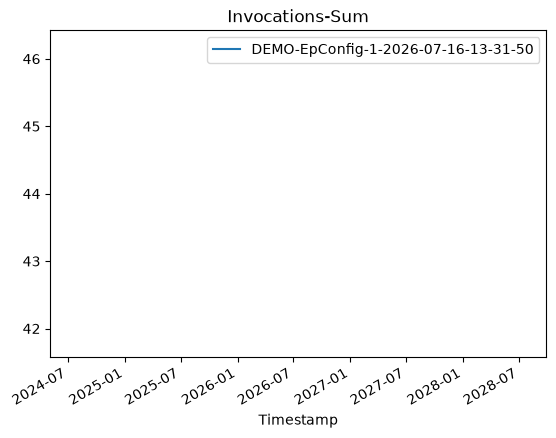

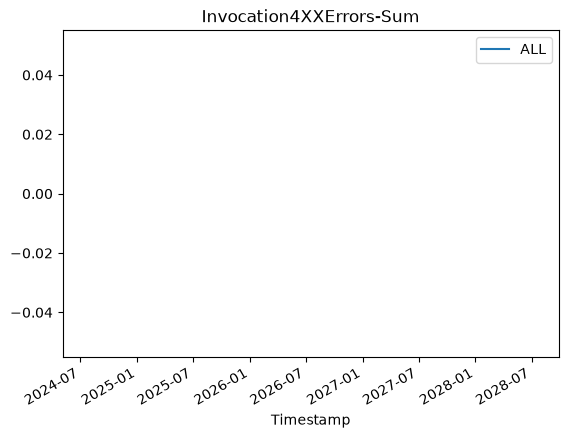

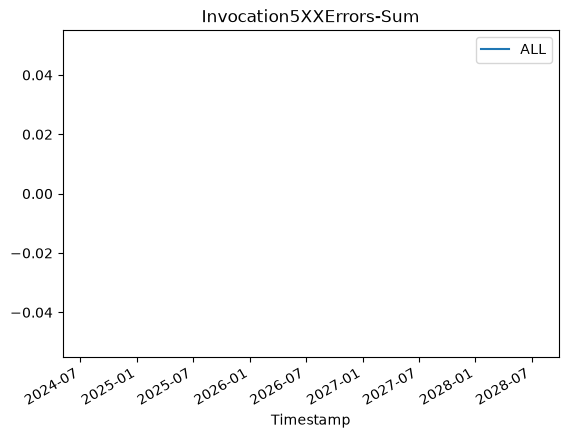

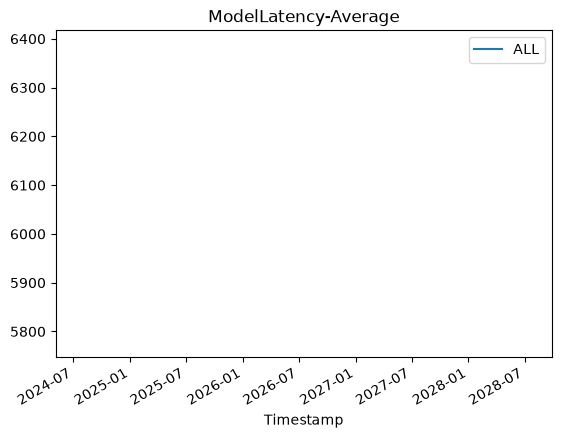

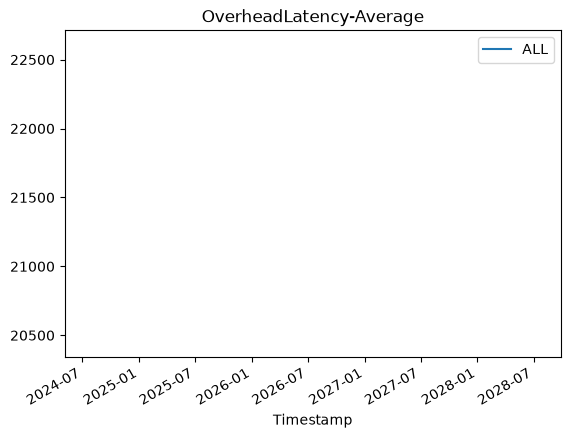

In [12]:
invocation_metrics = plot_endpoint_invocation_metrics(
    endpoint_name, ep_config_name, "AllTraffic", "Invocations", "Sum"
)
invocation_4xx_metrics = plot_endpoint_invocation_metrics(
    endpoint_name, None, "AllTraffic", "Invocation4XXErrors", "Sum"
)
invocation_5xx_metrics = plot_endpoint_invocation_metrics(
    endpoint_name, None, "AllTraffic", "Invocation5XXErrors", "Sum"
)
model_latency_metrics = plot_endpoint_invocation_metrics(
    endpoint_name, None, "AllTraffic", "ModelLatency", "Average"
)
overhead_latency_metrics = plot_endpoint_invocation_metrics(
    endpoint_name, None, "AllTraffic", "OverheadLatency", "Average"
)

# Step 3: Create CloudWatch alarms to monitor Endpoint performance <a id='Step3'></a>

In this step we're going to create CloudWatch alarms to monitor Endpoint performance with following metrics:
* Invocation5XXErrors
* ModelLatency

Following metric dimensions are used to select the metric per Endpoint config and variant:
* EndpointName
* VariantName


In [13]:
def create_auto_rollback_alarm(
    alarm_name, endpoint_name, variant_name, metric_name, statistic, threshold
):
    cw.put_metric_alarm(
        AlarmName=alarm_name,
        AlarmDescription="Test SageMaker endpoint deployment auto-rollback alarm",
        ActionsEnabled=False,
        Namespace="AWS/SageMaker",
        MetricName=metric_name,
        Statistic=statistic,
        Dimensions=[
            {"Name": "EndpointName", "Value": endpoint_name},
            {"Name": "VariantName", "Value": variant_name},
        ],
        Period=60,
        EvaluationPeriods=1,
        Threshold=threshold,
        ComparisonOperator="GreaterThanOrEqualToThreshold",
        TreatMissingData="notBreaching",
    )

In [14]:
error_alarm = f"TestAlarm-5XXErrors-{endpoint_name}"
latency_alarm = f"TestAlarm-ModelLatency-{endpoint_name}"

# alarm on 1% 5xx error rate for 1 minute
create_auto_rollback_alarm(
    error_alarm, endpoint_name, "AllTraffic", "Invocation5XXErrors", "Average", 1
)
# alarm on model latency >= 10 ms for 1 minute
create_auto_rollback_alarm(
    latency_alarm, endpoint_name, "AllTraffic", "ModelLatency", "Average", 10000
)

In [15]:
cw.describe_alarms(AlarmNames=[error_alarm, latency_alarm])
time.sleep(60)

# Step 4: Update Endpoint with deployment configurations <a id='Step4'></a>

Now we try to update the endpoint with deployment configurations and monitor the performance from CloudWatch metrics.


### BlueGreen update policy with Linear traffic shifting

We define the following deployment configuration to perform Blue/Green update strategy with Linear traffic shifting from old to new stack. The Linear traffic shifting option can reduce the blast ratio of a regressive update to the endpoint. In contrast, for the All-At-Once traffic shifting option, the invocation requests start failing at 100% after flipping the traffic. In the Linear mode, invocation requests are shifted to the new version of the model gradually, with a controlled percentage of traffic shifting for each step. You can use the auto-rollback alarms to monitor the metrics during the linear traffic shifting stage.

### Rollback Case
![Rollback case](images/scenario-linear-rollback.png)

Update the Endpoint with an incompatible model version to simulate errors and trigger a rollback.

In [16]:
linear_deployment_config = {
    "BlueGreenUpdatePolicy": {
        "TrafficRoutingConfiguration": {
            "Type": "LINEAR",
            "LinearStepSize": {
                "Type": "CAPACITY_PERCENT",
                "Value": 33,  # 33% of whole fleet capacity (33% * 3 = 1 instance)
            },
            "WaitIntervalInSeconds": 180,  # wait for 3 minutes before enabling traffic on the rest of fleet
        },
        "TerminationWaitInSeconds": 120,  # wait for 2 minutes before terminating the old stack
        "MaximumExecutionTimeoutInSeconds": 1800,  # maximum timeout for deployment
    },
    "AutoRollbackConfiguration": {
        "Alarms": [{"AlarmName": error_alarm}, {"AlarmName": latency_alarm}],
    },
}

# update endpoint request with new DeploymentConfig parameter
sm.update_endpoint(
    EndpointName=endpoint_name,
    EndpointConfigName=ep_config_name2,
    DeploymentConfig=linear_deployment_config,
)

{'EndpointArn': 'arn:aws:sagemaker:us-west-1:729646638167:endpoint/DEMO-Deployment-Guardrails-Linear-2026-07-16-13-32-06',
 'ResponseMetadata': {'RequestId': '90f1927c-2172-4d31-9566-c3c5dbd3c77a',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amzn-requestid': '90f1927c-2172-4d31-9566-c3c5dbd3c77a',
   'strict-transport-security': 'max-age=47304000; includeSubDomains',
   'x-frame-options': 'DENY',
   'content-security-policy': "frame-ancestors 'none'",
   'cache-control': 'no-cache, no-store, must-revalidate',
   'x-content-type-options': 'nosniff',
   'content-type': 'application/x-amz-json-1.1',
   'content-length': '121',
   'date': 'Thu, 16 Jul 2026 20:37:51 GMT'},
  'RetryAttempts': 0}}

In [17]:
sm.describe_endpoint(EndpointName=endpoint_name)

{'EndpointName': 'DEMO-Deployment-Guardrails-Linear-2026-07-16-13-32-06',
 'EndpointArn': 'arn:aws:sagemaker:us-west-1:729646638167:endpoint/DEMO-Deployment-Guardrails-Linear-2026-07-16-13-32-06',
 'EndpointConfigName': 'DEMO-EpConfig-1-2026-07-16-13-31-50',
 'ProductionVariants': [{'VariantName': 'AllTraffic',
   'DeployedImages': [{'SpecifiedImage': '746614075791.dkr.ecr.us-west-1.amazonaws.com/sagemaker-xgboost:0.90-1-cpu-py3',
     'ResolvedImage': '746614075791.dkr.ecr.us-west-1.amazonaws.com/sagemaker-xgboost@sha256:4814427c3e0a6cf99e637704da3ada04219ac7cd5727ff62284153761d36d7d3',
     'ResolutionTime': datetime.datetime(2026, 7, 16, 13, 32, 7, 499000, tzinfo=tzlocal())}],
   'CurrentWeight': 1.0,
   'DesiredWeight': 1.0,
   'CurrentInstanceCount': 3,
   'DesiredInstanceCount': 3}],
 'EndpointStatus': 'Updating',
 'CreationTime': datetime.datetime(2026, 7, 16, 13, 32, 7, 53000, tzinfo=tzlocal()),
 'LastModifiedTime': datetime.datetime(2026, 7, 16, 13, 37, 51, 977000, tzinfo=tzlo

### We invoke the endpoint during the update operation is in progress.

**Note : Invoke endpoint in this notebook is in single thread mode, to stop the invoke requests please stop the cell execution**

The E's denote the errors generated from the incompatible model version in the linear fleet.

The purpose of the below cell is to simulate errors in the linear fleet. Since the nature of traffic shifting to the linear fleet is probabilistic, you should wait until you start seeing errors. Then, you may proceed to stop the execution of the below cell. If not aborted, cell will run for 600 invocations.

In [18]:
invoke_endpoint(endpoint_name)

Sending test traffic to the endpoint DEMO-Deployment-Guardrails-Linear-2026-07-16-13-32-06. 
Please wait...
.

.

.

.

.

...

.

.

.

.


Done!


Wait for the update operation to complete and verify the automatic rollback.

In [19]:
wait_for_endpoint_in_service(endpoint_name)

sm.describe_endpoint(EndpointName=endpoint_name)

Waiting for endpoint in service



Done!


{'EndpointName': 'DEMO-Deployment-Guardrails-Linear-2026-07-16-13-32-06',
 'EndpointArn': 'arn:aws:sagemaker:us-west-1:729646638167:endpoint/DEMO-Deployment-Guardrails-Linear-2026-07-16-13-32-06',
 'EndpointConfigName': 'DEMO-EpConfig-1-2026-07-16-13-31-50',
 'ProductionVariants': [{'VariantName': 'AllTraffic',
   'DeployedImages': [{'SpecifiedImage': '746614075791.dkr.ecr.us-west-1.amazonaws.com/sagemaker-xgboost:0.90-1-cpu-py3',
     'ResolvedImage': '746614075791.dkr.ecr.us-west-1.amazonaws.com/sagemaker-xgboost@sha256:4814427c3e0a6cf99e637704da3ada04219ac7cd5727ff62284153761d36d7d3',
     'ResolutionTime': datetime.datetime(2026, 7, 16, 13, 32, 7, 499000, tzinfo=tzlocal())}],
   'CurrentWeight': 1.0,
   'DesiredWeight': 1.0,
   'CurrentInstanceCount': 3,
   'DesiredInstanceCount': 3}],
 'EndpointStatus': 'InService',
 'FailureReason': 'One or more configured alarm for automatic rollback deployment is in ALARM state: [TestAlarm-ModelLatency-DEMO-Deployment-Guardrails-Linear-2026-07-

Collect the endpoint metrics during the deployment:

Below, we are going to plot graphs to show the Invocations,Invocation5XXErrors and ModelLatency against the Endpoint.

You can expect to see as the new endpoint config-2 (erroneous due to model version) starts getting deployed, it encounters failure and leads to the rollback to endpoint config-1. This can be seen in the graphs below as the Invocation5XXErrors and ModelLatency increases during this rollback phase


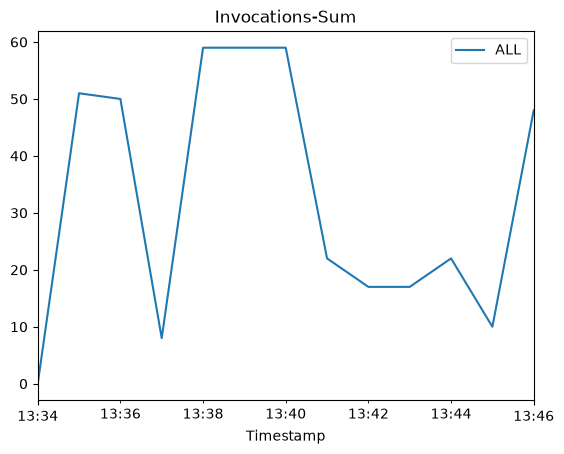

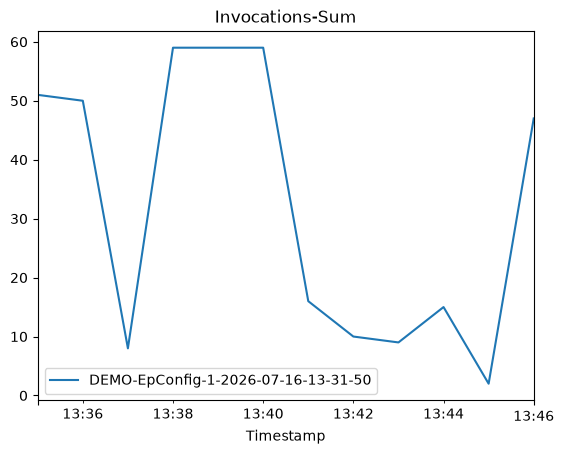

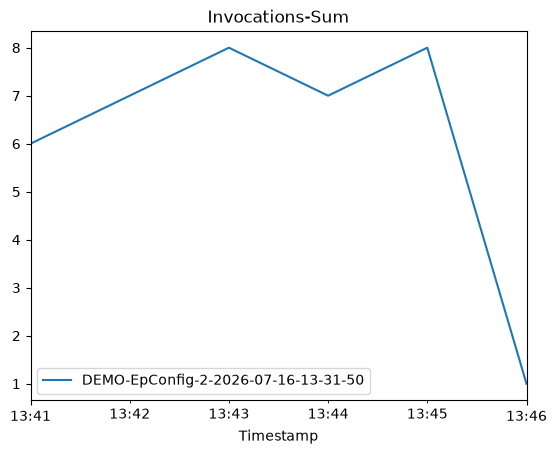

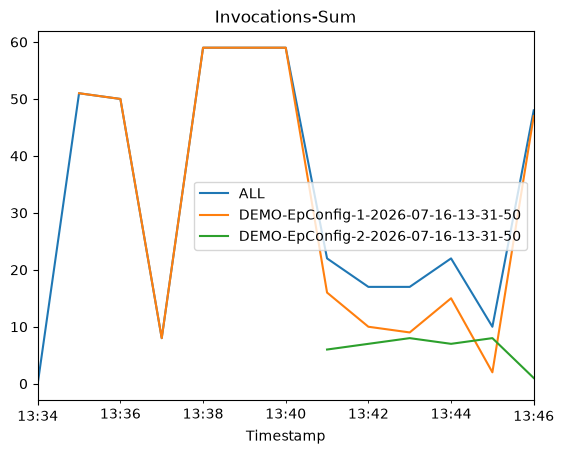

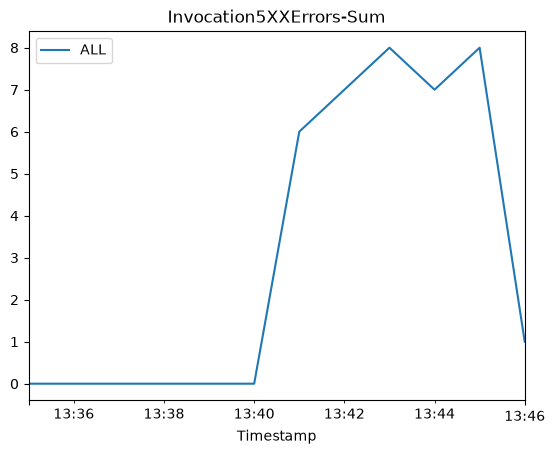

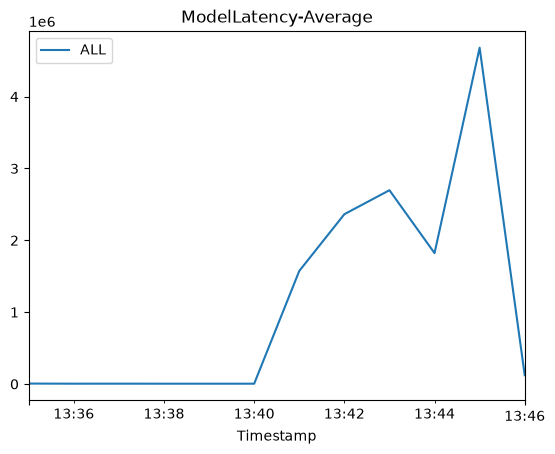

In [20]:
invocation_metrics = plot_endpoint_invocation_metrics(
    endpoint_name, None, "AllTraffic", "Invocations", "Sum"
)
metrics_epc_1 = plot_endpoint_invocation_metrics(
    endpoint_name, ep_config_name, "AllTraffic", "Invocations", "Sum"
)
metrics_epc_2 = plot_endpoint_invocation_metrics(
    endpoint_name, ep_config_name2, "AllTraffic", "Invocations", "Sum"
)

# Some per-endpoint-config Invocations metrics may not have CloudWatch datapoints
# yet (metric aggregation lag), in which case plot_endpoint_invocation_metrics
# returns None. Join only the frames that actually have data.
_frames = [m for m in [invocation_metrics, metrics_epc_1, metrics_epc_2] if m is not None]
if _frames:
    metrics_all = _frames[0].join(_frames[1:], how="outer")
    metrics_all.plot(title="Invocations-Sum")

invocation_5xx_metrics = plot_endpoint_invocation_metrics(
    endpoint_name, None, "AllTraffic", "Invocation5XXErrors", "Sum"
)
model_latency_metrics = plot_endpoint_invocation_metrics(
    endpoint_name, None, "AllTraffic", "ModelLatency", "Average"
)

Let's take a look at the Success case where we use the same Linear deployment configuration but a valid endpoint configuration.

### Success Case
![Success case](images/scenario-linear-success.png)

Now let's update the endpoint to a valid endpoint configuration version with the same Linear deployment configuration:

In [21]:
# update endpoint with a valid version of DeploymentConfig

sm.update_endpoint(
    EndpointName=endpoint_name,
    EndpointConfigName=ep_config_name3,
    RetainDeploymentConfig=True,
)

{'EndpointArn': 'arn:aws:sagemaker:us-west-1:729646638167:endpoint/DEMO-Deployment-Guardrails-Linear-2026-07-16-13-32-06',
 'ResponseMetadata': {'RequestId': '9b637bc0-1be5-4a5e-9d9a-7223c09491e1',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amzn-requestid': '9b637bc0-1be5-4a5e-9d9a-7223c09491e1',
   'strict-transport-security': 'max-age=47304000; includeSubDomains',
   'x-frame-options': 'DENY',
   'content-security-policy': "frame-ancestors 'none'",
   'cache-control': 'no-cache, no-store, must-revalidate',
   'x-content-type-options': 'nosniff',
   'content-type': 'application/x-amz-json-1.1',
   'content-length': '121',
   'date': 'Thu, 16 Jul 2026 20:47:09 GMT'},
  'RetryAttempts': 0}}

In [22]:
sm.describe_endpoint(EndpointName=endpoint_name)

{'EndpointName': 'DEMO-Deployment-Guardrails-Linear-2026-07-16-13-32-06',
 'EndpointArn': 'arn:aws:sagemaker:us-west-1:729646638167:endpoint/DEMO-Deployment-Guardrails-Linear-2026-07-16-13-32-06',
 'EndpointConfigName': 'DEMO-EpConfig-1-2026-07-16-13-31-50',
 'ProductionVariants': [{'VariantName': 'AllTraffic',
   'DeployedImages': [{'SpecifiedImage': '746614075791.dkr.ecr.us-west-1.amazonaws.com/sagemaker-xgboost:0.90-1-cpu-py3',
     'ResolvedImage': '746614075791.dkr.ecr.us-west-1.amazonaws.com/sagemaker-xgboost@sha256:4814427c3e0a6cf99e637704da3ada04219ac7cd5727ff62284153761d36d7d3',
     'ResolutionTime': datetime.datetime(2026, 7, 16, 13, 32, 7, 499000, tzinfo=tzlocal())}],
   'CurrentWeight': 1.0,
   'DesiredWeight': 1.0,
   'CurrentInstanceCount': 3,
   'DesiredInstanceCount': 3}],
 'EndpointStatus': 'Updating',
 'FailureReason': 'One or more configured alarm for automatic rollback deployment is in ALARM state: [TestAlarm-ModelLatency-DEMO-Deployment-Guardrails-Linear-2026-07-1

We invoke the endpoint during the update operation is in progress:

In [23]:
invoke_endpoint(endpoint_name, max_invocations=500)

Sending test traffic to the endpoint DEMO-Deployment-Guardrails-Linear-2026-07-16-13-32-06. 
Please wait...
.

.

.

.

.

...

.

.

.

.


Done!


Wait for the update operation to complete:

In [24]:
wait_for_endpoint_in_service(endpoint_name)

sm.describe_endpoint(EndpointName=endpoint_name)

Waiting for endpoint in service



Done!


{'EndpointName': 'DEMO-Deployment-Guardrails-Linear-2026-07-16-13-32-06',
 'EndpointArn': 'arn:aws:sagemaker:us-west-1:729646638167:endpoint/DEMO-Deployment-Guardrails-Linear-2026-07-16-13-32-06',
 'EndpointConfigName': 'DEMO-EpConfig-1-2026-07-16-13-31-50',
 'ProductionVariants': [{'VariantName': 'AllTraffic',
   'DeployedImages': [{'SpecifiedImage': '746614075791.dkr.ecr.us-west-1.amazonaws.com/sagemaker-xgboost:0.90-1-cpu-py3',
     'ResolvedImage': '746614075791.dkr.ecr.us-west-1.amazonaws.com/sagemaker-xgboost@sha256:4814427c3e0a6cf99e637704da3ada04219ac7cd5727ff62284153761d36d7d3',
     'ResolutionTime': datetime.datetime(2026, 7, 16, 13, 32, 7, 499000, tzinfo=tzlocal())}],
   'CurrentWeight': 1.0,
   'DesiredWeight': 1.0,
   'CurrentInstanceCount': 3,
   'DesiredInstanceCount': 3}],
 'EndpointStatus': 'InService',
 'FailureReason': 'One or more configured alarm for automatic rollback deployment is in ALARM state: [TestAlarm-ModelLatency-DEMO-Deployment-Guardrails-Linear-2026-07-

Collect the endpoint metrics during the deployment:

Below, we are going to plot graphs to show the Invocations,Invocation5XXErrors and ModelLatency against the Endpoint.

You can expect to see that, as the new endpoint config-3 (correct model version) starts getting deployed, it takes over endpoint config-2 (erroneous due to model version) without any errors. This can be seen in the graphs below as the Invocation5XXErrors and ModelLatency decreases during this transition phase


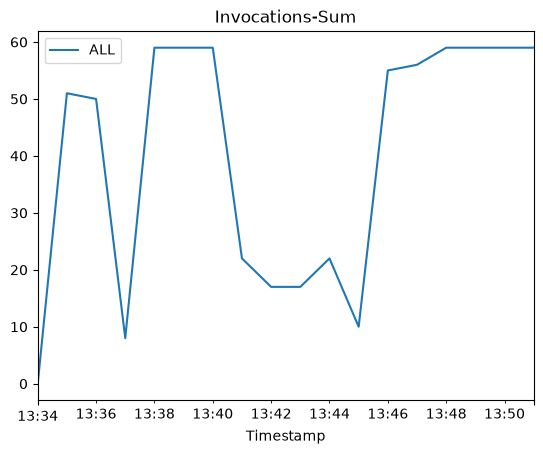

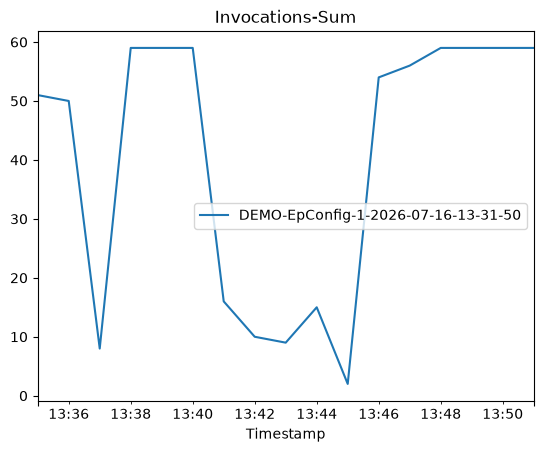

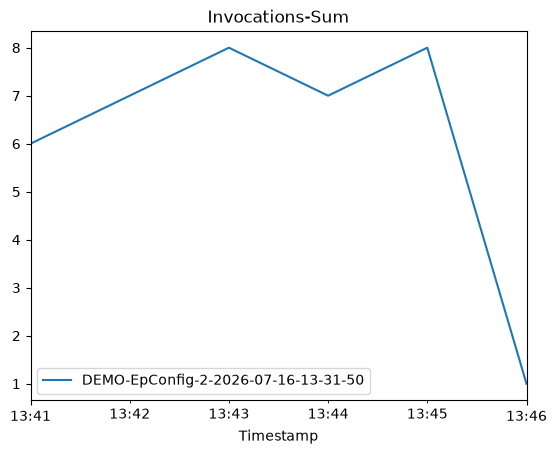

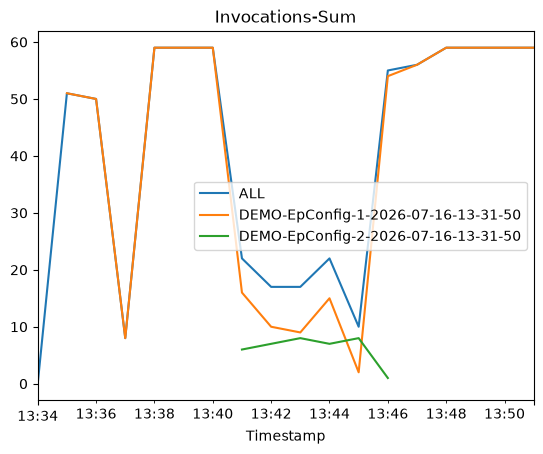

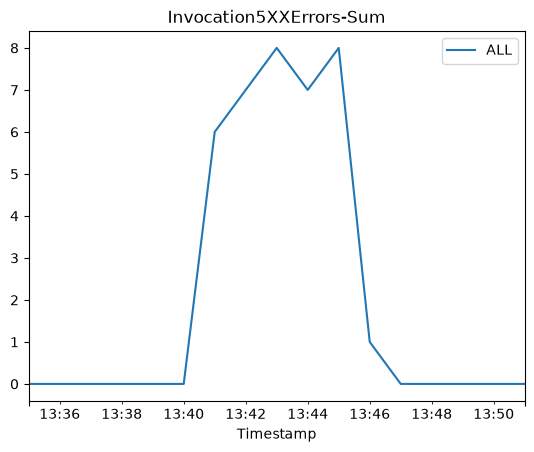

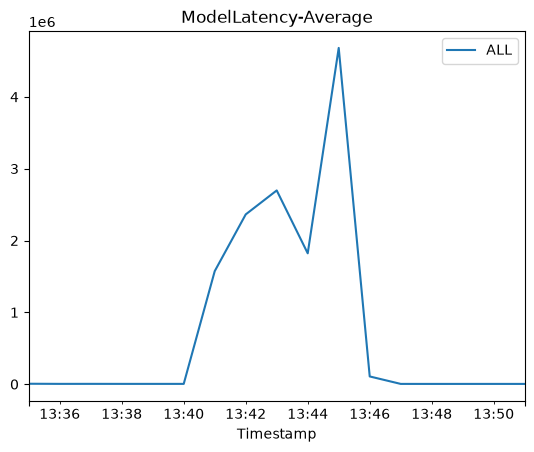

In [25]:
invocation_metrics = plot_endpoint_invocation_metrics(
    endpoint_name, None, "AllTraffic", "Invocations", "Sum"
)
metrics_epc_1 = plot_endpoint_invocation_metrics(
    endpoint_name, ep_config_name, "AllTraffic", "Invocations", "Sum"
)
metrics_epc_2 = plot_endpoint_invocation_metrics(
    endpoint_name, ep_config_name2, "AllTraffic", "Invocations", "Sum"
)
metrics_epc_3 = plot_endpoint_invocation_metrics(
    endpoint_name, ep_config_name3, "AllTraffic", "Invocations", "Sum"
)

# Some per-endpoint-config Invocations metrics may not have CloudWatch datapoints
# yet (metric aggregation lag), in which case plot_endpoint_invocation_metrics
# returns None. Join only the frames that actually have data.
_frames = [m for m in [invocation_metrics, metrics_epc_1, metrics_epc_2, metrics_epc_3] if m is not None]
if _frames:
    metrics_all = _frames[0].join(_frames[1:], how="outer")
    metrics_all.plot(title="Invocations-Sum")

invocation_5xx_metrics = plot_endpoint_invocation_metrics(
    endpoint_name, None, "AllTraffic", "Invocation5XXErrors", "Sum"
)
model_latency_metrics = plot_endpoint_invocation_metrics(
    endpoint_name, None, "AllTraffic", "ModelLatency", "Average"
)

The Amazon CloudWatch metrics for the total invocations for each endpoint config shows how invocation requests are shifted from the old version to the new version during deployment.

You can now safely update your endpoint and monitor model regressions during deployment and trigger auto-rollback action.

# Cleanup <a id='Cleanup'></a>

If you do not plan to use this endpoint further, you should delete the endpoint to avoid incurring additional charges.

You should also clean up the other resources created in this notebook: endpoint configurations, models, and CloudWatch alarms.

In [26]:
sm.delete_endpoint(EndpointName=endpoint_name)

{'ResponseMetadata': {'RequestId': 'e91fa6e1-3117-49f2-a9c6-b9af0068a125',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amzn-requestid': 'e91fa6e1-3117-49f2-a9c6-b9af0068a125',
   'strict-transport-security': 'max-age=47304000; includeSubDomains',
   'x-frame-options': 'DENY',
   'content-security-policy': "frame-ancestors 'none'",
   'cache-control': 'no-cache, no-store, must-revalidate',
   'x-content-type-options': 'nosniff',
   'content-type': 'application/x-amz-json-1.1',
   'date': 'Thu, 16 Jul 2026 20:52:50 GMT',
   'content-length': '0'},
  'RetryAttempts': 0}}

In [27]:
sm.delete_endpoint_config(EndpointConfigName=ep_config_name)
sm.delete_endpoint_config(EndpointConfigName=ep_config_name2)
sm.delete_endpoint_config(EndpointConfigName=ep_config_name3)

{'ResponseMetadata': {'RequestId': 'c8b9e9ac-1c76-4675-b0a5-87adf5d17af8',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amzn-requestid': 'c8b9e9ac-1c76-4675-b0a5-87adf5d17af8',
   'strict-transport-security': 'max-age=47304000; includeSubDomains',
   'x-frame-options': 'DENY',
   'content-security-policy': "frame-ancestors 'none'",
   'cache-control': 'no-cache, no-store, must-revalidate',
   'x-content-type-options': 'nosniff',
   'content-type': 'application/x-amz-json-1.1',
   'date': 'Thu, 16 Jul 2026 20:52:52 GMT',
   'content-length': '0'},
  'RetryAttempts': 2}}

In [28]:
sm.delete_model(ModelName=model_name)
sm.delete_model(ModelName=model_name2)
sm.delete_model(ModelName=model_name3)

{'ResponseMetadata': {'RequestId': '6122ff05-f72b-4846-a097-b069f06d0d00',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amzn-requestid': '6122ff05-f72b-4846-a097-b069f06d0d00',
   'strict-transport-security': 'max-age=47304000; includeSubDomains',
   'x-frame-options': 'DENY',
   'content-security-policy': "frame-ancestors 'none'",
   'cache-control': 'no-cache, no-store, must-revalidate',
   'x-content-type-options': 'nosniff',
   'content-type': 'application/x-amz-json-1.1',
   'date': 'Thu, 16 Jul 2026 20:52:56 GMT',
   'content-length': '0'},
  'RetryAttempts': 2}}

In [29]:
cw.delete_alarms(AlarmNames=[error_alarm, latency_alarm])

{'ResponseMetadata': {'RequestId': '7873fe45-4c67-458d-bebe-8dff8617ebb2',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amzn-requestid': '7873fe45-4c67-458d-bebe-8dff8617ebb2',
   'content-type': 'application/x-amz-json-1.0',
   'content-length': '0',
   'date': 'Thu, 16 Jul 2026 20:52:56 GMT'},
  'RetryAttempts': 0}}

## Notebook CI Test Results

This notebook was tested in multiple regions. The test results are as follows, except for us-west-2 which is shown at the top of the notebook.

![This us-east-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-east-1/deploy_and_monitor|sm-deployment_guardrails_update_inference_endpoint_with_linear_traffic_shifting|sm-deployment_guardrails_update_inference_endpoint_with_linear_traffic_shifting.ipynb)

![This us-east-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-east-2/deploy_and_monitor|sm-deployment_guardrails_update_inference_endpoint_with_linear_traffic_shifting|sm-deployment_guardrails_update_inference_endpoint_with_linear_traffic_shifting.ipynb)

![This us-west-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-west-1/deploy_and_monitor|sm-deployment_guardrails_update_inference_endpoint_with_linear_traffic_shifting|sm-deployment_guardrails_update_inference_endpoint_with_linear_traffic_shifting.ipynb)

![This ca-central-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ca-central-1/deploy_and_monitor|sm-deployment_guardrails_update_inference_endpoint_with_linear_traffic_shifting|sm-deployment_guardrails_update_inference_endpoint_with_linear_traffic_shifting.ipynb)

![This sa-east-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/sa-east-1/deploy_and_monitor|sm-deployment_guardrails_update_inference_endpoint_with_linear_traffic_shifting|sm-deployment_guardrails_update_inference_endpoint_with_linear_traffic_shifting.ipynb)

![This eu-west-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-1/deploy_and_monitor|sm-deployment_guardrails_update_inference_endpoint_with_linear_traffic_shifting|sm-deployment_guardrails_update_inference_endpoint_with_linear_traffic_shifting.ipynb)

![This eu-west-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-2/deploy_and_monitor|sm-deployment_guardrails_update_inference_endpoint_with_linear_traffic_shifting|sm-deployment_guardrails_update_inference_endpoint_with_linear_traffic_shifting.ipynb)

![This eu-west-3 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-3/deploy_and_monitor|sm-deployment_guardrails_update_inference_endpoint_with_linear_traffic_shifting|sm-deployment_guardrails_update_inference_endpoint_with_linear_traffic_shifting.ipynb)

![This eu-central-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-central-1/deploy_and_monitor|sm-deployment_guardrails_update_inference_endpoint_with_linear_traffic_shifting|sm-deployment_guardrails_update_inference_endpoint_with_linear_traffic_shifting.ipynb)

![This eu-north-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-north-1/deploy_and_monitor|sm-deployment_guardrails_update_inference_endpoint_with_linear_traffic_shifting|sm-deployment_guardrails_update_inference_endpoint_with_linear_traffic_shifting.ipynb)

![This ap-southeast-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-southeast-1/deploy_and_monitor|sm-deployment_guardrails_update_inference_endpoint_with_linear_traffic_shifting|sm-deployment_guardrails_update_inference_endpoint_with_linear_traffic_shifting.ipynb)

![This ap-southeast-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-southeast-2/deploy_and_monitor|sm-deployment_guardrails_update_inference_endpoint_with_linear_traffic_shifting|sm-deployment_guardrails_update_inference_endpoint_with_linear_traffic_shifting.ipynb)

![This ap-northeast-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-northeast-1/deploy_and_monitor|sm-deployment_guardrails_update_inference_endpoint_with_linear_traffic_shifting|sm-deployment_guardrails_update_inference_endpoint_with_linear_traffic_shifting.ipynb)

![This ap-northeast-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-northeast-2/deploy_and_monitor|sm-deployment_guardrails_update_inference_endpoint_with_linear_traffic_shifting|sm-deployment_guardrails_update_inference_endpoint_with_linear_traffic_shifting.ipynb)

![This ap-south-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-south-1/deploy_and_monitor|sm-deployment_guardrails_update_inference_endpoint_with_linear_traffic_shifting|sm-deployment_guardrails_update_inference_endpoint_with_linear_traffic_shifting.ipynb)
